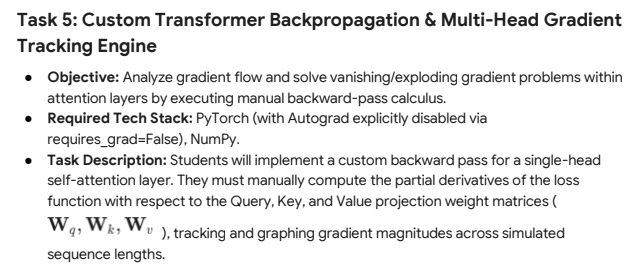

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


In [ ]:
# 1. SOFTMAX

def softmax(x):

    x = x - np.max(
        x,
        axis=-1,
        keepdims=True
    )

    exp_x = np.exp(x)

    return exp_x / np.sum(
        exp_x,
        axis=-1,
        keepdims=True
    )

In [ ]:
# 2. PARAMETERS

sequence_length = 8
embedding_dim = 16

X = np.random.randn(
    sequence_length,
    embedding_dim
)


Wq = np.random.randn(
    embedding_dim,
    embedding_dim
) * 0.1

Wk = np.random.randn(
    embedding_dim,
    embedding_dim
) * 0.1

Wv = np.random.randn(
    embedding_dim,
    embedding_dim
) * 0.1

In [ ]:
# 3. FORWARD PASS

Q = X @ Wq

K = X @ Wk

V = X @ Wv


dk = embedding_dim

scores = (
    Q @ K.T
) / np.sqrt(dk)


A = softmax(scores)


O = A @ V


In [ ]:
# 4. LOSS

loss = 0.5 * np.sum(
    O ** 2
)

print(
    "Forward loss:",
    loss
)


# 5. MANUAL BACKWARD PASS

# dL/dO
dO = O.copy()


# O = A @ V

# dL/dA
dA = dO @ V.T

# dL/dV
dV = A.T @ dO


# 6. SOFTMAX BACKWARD


dScores = np.zeros_like(
    scores
)

for i in range(
    sequence_length
):

    s = A[i].reshape(
        -1,
        1
    )

    jacobian = (
        np.diagflat(s)
        - s @ s.T
    )

    dScores[i] = (
        jacobian @ dA[i]
    )


# 7. SCALE GRADIENT


dScores /= np.sqrt(dk)

# 8. BACKPROPAGATE THROUGH Q @ K.T


dQ = dScores @ K

dK = dScores.T @ Q


# 9. BACKPROPAGATE THROUGH PROJECTIONS


dWq = X.T @ dQ

dWk = X.T @ dK

dWv = X.T @ dV


Forward loss: 1.6737044145223103



Gradient magnitudes
||dWq|| = 0.7262988930057905
||dWk|| = 0.6101759590444212
||dWv|| = 7.011225150170011


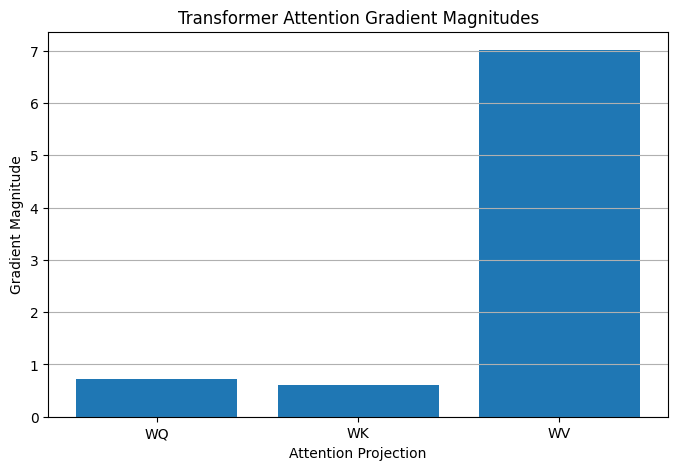

In [ ]:
# 10. PRINT GRADIENTS


print("\nGradient magnitudes")

print(
    "||dWq|| =",
    np.linalg.norm(dWq)
)

print(
    "||dWk|| =",
    np.linalg.norm(dWk)
)

print(
    "||dWv|| =",
    np.linalg.norm(dWv)
)

# 11. GRADIENT TRACKING


gradient_names = [
    "WQ",
    "WK",
    "WV"
]

gradient_values = [
    np.linalg.norm(dWq),
    np.linalg.norm(dWk),
    np.linalg.norm(dWv)
]


# 12. VISUALIZE GRADIENT MAGNITUDES


plt.figure(figsize=(8, 5))

plt.bar(
    gradient_names,
    gradient_values
)

plt.xlabel(
    "Attention Projection"
)

plt.ylabel(
    "Gradient Magnitude"
)

plt.title(
    "Transformer Attention Gradient Magnitudes"
)

plt.grid(
    axis="y"
)

plt.show()

In [ ]:
# GRADIENT TRACKING ACROSS TRAINING

learning_rate = 0.01
steps = 100

history_WQ = []
history_WK = []
history_WV = []
loss_history = []


for step in range(steps):

    # Forward
    Q = X @ Wq
    K = X @ Wk
    V = X @ Wv

    scores = (
        Q @ K.T
    ) / np.sqrt(dk)

    A = softmax(scores)

    O = A @ V

    loss = 0.5 * np.sum(O ** 2)

    # Backward
    dO = O.copy()

    dA = dO @ V.T
    dV = A.T @ dO

    dScores = np.zeros_like(scores)

    for i in range(sequence_length):

        s = A[i].reshape(-1, 1)

        jacobian = (
            np.diagflat(s)
            - s @ s.T
        )

        dScores[i] = (
            jacobian @ dA[i]
        )

    dScores /= np.sqrt(dk)

    dQ = dScores @ K
    dK = dScores.T @ Q

    dWq = X.T @ dQ
    dWk = X.T @ dK
    dWv = X.T @ dV

    # Record gradients
    history_WQ.append(
        np.linalg.norm(dWq)
    )

    history_WK.append(
        np.linalg.norm(dWk)
    )

    history_WV.append(
        np.linalg.norm(dWv)
    )

    loss_history.append(loss)

    # Parameter update
    Wq -= learning_rate * dWq
    Wk -= learning_rate * dWk
    Wv -= learning_rate * dWv


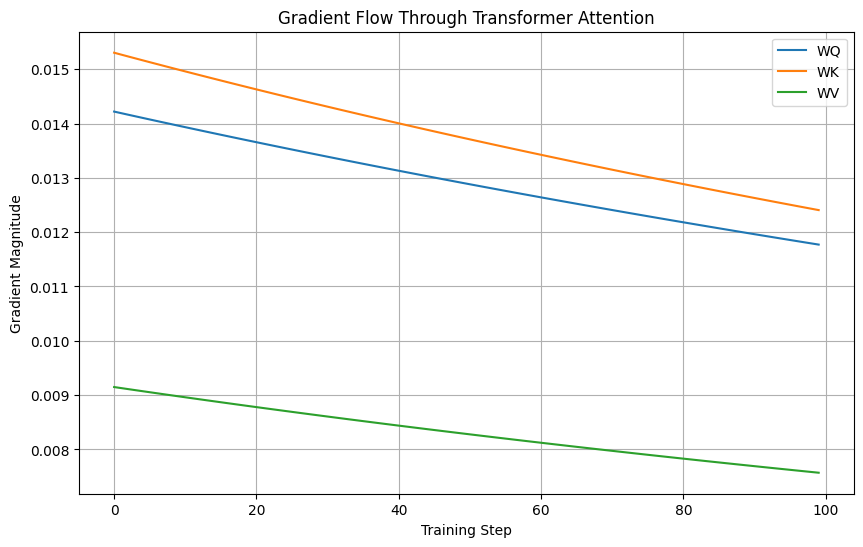

In [ ]:
# PLOT GRADIENTS

plt.figure(figsize=(10, 6))

plt.plot(
    history_WQ,
    label="WQ"
)

plt.plot(
    history_WK,
    label="WK"
)

plt.plot(
    history_WV,
    label="WV"
)

plt.xlabel("Training Step")
plt.ylabel("Gradient Magnitude")

plt.title(
    "Gradient Flow Through Transformer Attention"
)

plt.legend()

plt.grid()

plt.show()